#Cell 1: Mount Google Drive & Setup Project Structure

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive')
!mkdir -p urban_sound_project_90
os.chdir('/content/drive/MyDrive/urban_sound_project_90')

print(f"📁 Working in: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Working in: /content/drive/MyDrive/urban_sound_project_90


#Cell 2: Install & Import


In [ ]:
!pip install -q soundata librosa tensorflow matplotlib scikit-learn seaborn gradio

import soundata, librosa, tensorflow as tf
import numpy as np, matplotlib.pyplot as plt, pickle, os, warnings
import seaborn as sns
import gradio as gr
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from pathlib import Path
from tqdm import tqdm
warnings.filterwarnings('ignore')

print(f"✅ TensorFlow: {tf.__version__}")
print(f"✅ GPU: {bool(tf.config.list_physical_devices('GPU'))}")

✅ TensorFlow: 2.20.0
✅ GPU: False


#Cell 3: Download Dataset

In [ ]:
print("🔄 Initializing UrbanSound8K...")
dataset = soundata.initialize('urbansound8k', data_home='./data')
dataset.download() # Download the dataset index and audio files if not present

my_classes = ['dog_bark', 'car_horn', 'engine_idling', 'siren', 'street_music']
print(f"🎯 Classes: {my_classes}")

selected_clips = []
for clip_id in dataset.clip_ids:
    clip = dataset.clip(clip_id)
    if clip.class_label in my_classes:
        selected_clips.append({
            'clip_id': clip.clip_id,
            'class_label': clip.class_label,
            'audio_path': clip.audio_path
        })

print(f"📊 Found {len(selected_clips)} audio clips")

# Download audio files (if not already present)
print("📥 Downloading audio files (10-15 min)...")
for i, clip in enumerate(selected_clips):
    try:
        _ = dataset.clip(clip['clip_id']).audio
        if (i+1) % 100 == 0:
            print(f"📥 {i+1}/{len(selected_clips)}")
    except:
        pass

# Train/test split
train_clips, test_clips = train_test_split(
    selected_clips,
    test_size=0.2,
    random_state=42,
    stratify=[c['class_label'] for c in selected_clips]
)

with open('./data/split_info.pkl', 'wb') as f:
    pickle.dump({'train': train_clips, 'test': test_clips}, f)

print(f"✅ Train: {len(train_clips)} | Test: {len(test_clips)}")

🔄 Initializing UrbanSound8K...


5.61GB [17:20, 5.79MB/s]                            
1.15MB [00:02, 416kB/s]                            


🎯 Classes: ['dog_bark', 'car_horn', 'engine_idling', 'siren', 'street_music']
📊 Found 4358 audio clips
📥 Downloading audio files (10-15 min)...
📥 100/4358
📥 200/4358
📥 300/4358
📥 400/4358
📥 500/4358
📥 600/4358
📥 700/4358
📥 800/4358
📥 900/4358
📥 1000/4358
📥 1100/4358
📥 1200/4358
📥 1300/4358
📥 1400/4358
📥 1500/4358
📥 1600/4358
📥 1700/4358
📥 1800/4358
📥 1900/4358
📥 2000/4358
📥 2100/4358
📥 2200/4358
📥 2300/4358
📥 2400/4358
📥 2500/4358
📥 2600/4358
📥 2700/4358
📥 2800/4358
📥 2900/4358
📥 3000/4358
📥 3100/4358
📥 3200/4358
📥 3300/4358
📥 3400/4358
📥 3500/4358
📥 3600/4358
📥 3700/4358
📥 3800/4358
📥 3900/4358
📥 4000/4358
📥 4100/4358
📥 4200/4358
📥 4300/4358
✅ Train: 3486 | Test: 872


#Cell 4: Convert to Higher Resolution Spectrograms (224x224)

In [ ]:
def audio_to_spectrogram(audio_path, output_path, target_size=(224, 224)):
    try:
        y, sr = librosa.load(audio_path, sr=22050, duration=4.0)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=224, n_fft=2048, hop_length=512)
        S_db = librosa.power_to_db(S, ref=np.max)

        if S_db.shape[1] < target_size[1]:
            pad_width = target_size[1] - S_db.shape[1]
            S_db = np.pad(S_db, ((0,0), (0, pad_width)), mode='constant')
        else:
            S_db = S_db[:, :target_size[1]]

        S_db = (S_db - S_db.min()) / (S_db.max() - S_db.min()) * 255
        S_db = S_db.astype(np.uint8)

        plt.figure(figsize=(target_size[1]/100, target_size[0]/100), dpi=100)
        plt.axis('off')
        plt.imshow(S_db, aspect='auto', cmap='gray')
        plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
        plt.close()
        return True
    except:
        return False

# Create folders
for split in ['train', 'test']:
    for class_name in my_classes:
        os.makedirs(f'./spectrograms/{split}/{class_name}', exist_ok=True)

with open('./data/split_info.pkl', 'rb') as f:
    split_info = pickle.load(f)

print("🔄 Converting to 224x224 spectrograms...")
total = 0
for split_name in ['train', 'test']:
    for clip in tqdm(split_info[split_name], desc=split_name):
        out = f'./spectrograms/{split_name}/{clip["class_label"]}/{clip["clip_id"]}.png'
        if not Path(out).exists():
            if audio_to_spectrogram(clip["audio_path"], out, target_size=(224, 224)):
                total += 1
        else:
            total += 1
    print(f"✅ {split_name}: {total} files")

print(f"✅ Total: {total} spectrograms")

🔄 Converting to 224x224 spectrograms...


train: 100%|██████████| 3486/3486 [08:59<00:00,  6.47it/s]


✅ train: 3486 files


test: 100%|██████████| 872/872 [02:02<00:00,  7.13it/s]

✅ test: 4358 files
✅ Total: 4358 spectrograms


#Cell 5: Load Data with Strong Augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    zoom_range=0.3,
    shear_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.15
)

test_datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 32

train_gen = train_datagen.flow_from_directory(
    './spectrograms/train',
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    './spectrograms/train',
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    subset='validation'
)

test_gen = test_datagen.flow_from_directory(
    './spectrograms/test',
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print(f"📋 Classes: {class_names}")
print(f"✅ Train: {train_gen.samples} | Val: {val_gen.samples} | Test: {test_gen.samples}")

# Class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))
print(f"📊 Class weights: {class_weight_dict}")

Found 2964 images belonging to 5 classes.
Found 522 images belonging to 5 classes.
Found 872 images belonging to 5 classes.
📋 Classes: ['car_horn', 'dog_bark', 'engine_idling', 'siren', 'street_music']
✅ Train: 2964 | Val: 522 | Test: 872
📊 Class weights: {0: np.float64(2.03013698630137), 1: np.float64(0.8717647058823529), 2: np.float64(0.8717647058823529), 3: np.float64(0.9379746835443038), 4: np.float64(0.8717647058823529)}


#Cell 6: TRANSFER LEARNING WITH MOBILENETV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2

def create_transfer_model():
    inputs = keras.Input(shape=(224, 224, 1))
    x = layers.Conv2D(3, (3, 3), padding='same')(inputs)

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(len(my_classes), activation='softmax')(x)

    model = keras.Model(inputs, outputs)

    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001,
        decay_steps=50,
        decay_rate=0.95,
        staircase=True
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = create_transfer_model()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 3)    │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,027 (10.00 MB)

 Trainable params: 362,275 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

#Cell 7: Train (Phase 1 - Transfer Learning)


In [ ]:
print("🚀 Phase 1: Training top layers (10-15 min)...")

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        './models/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

history1 = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("✅ Phase 1 complete!")

🚀 Phase 1: Training top layers (10-15 min)...
Epoch 1/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4596 - loss: 1.4689
Epoch 1: val_accuracy improved from None to 0.50383, saving model to ./models/best_model.keras

Epoch 1: finished saving model to ./models/best_model.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 397s 4s/step - accuracy: 0.5641 - loss: 1.2046 - val_accuracy: 0.5038 - val_loss: 1.2272 - learning_rate: 9.5000e-04
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6706 - loss: 0.8774
Epoch 2: val_accuracy improved from 0.50383 to 0.73563, saving model to ./models/best_model.keras

Epoch 2: finished saving model to ./models/best_model.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 369s 4s/step - accuracy: 0.6812 - loss: 0.8703 - val_accuracy: 0.7356 - val_loss: 0.7280 - learning_rate: 8.5737e-04
Epoch 3/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6982 - loss: 0.8496
Epoch 3: val_accuracy improved from 0.73563 to 0.76054, saving model to ./models/best_model.keras

Epo

#Cell 8: Fine-Tuning (Phase 2)

In [ ]:
print("🚀 Phase 2: Fine-tuning (unfreezing base model, 15-20 min)...")

model.layers[1].trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

# Load best model
if os.path.exists('./models/best_model.keras'):
    model = keras.models.load_model('./models/best_model.keras')
    print("✅ Loaded best fine-tuned model!")

# Save final model
model.save('./models/final_model.keras')
print(f"✅ Model saved! Size: {os.path.getsize('./models/final_model.keras') / 1024 / 1024:.2f} MB")

🚀 Phase 2: Fine-tuning (unfreezing base model, 15-20 min)...
Epoch 1/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7816 - loss: 0.5877
Epoch 1: val_accuracy did not improve from 0.80077
93/93 ━━━━━━━━━━━━━━━━━━━━ 408s 4s/step - accuracy: 0.7925 - loss: 0.5664 - val_accuracy: 0.7720 - val_loss: 0.6374 - learning_rate: 1.0000e-05
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7847 - loss: 0.5939
Epoch 2: val_accuracy did not improve from 0.80077
93/93 ━━━━━━━━━━━━━━━━━━━━ 378s 4s/step - accuracy: 0.7891 - loss: 0.5694 - val_accuracy: 0.7835 - val_loss: 0.6269 - learning_rate: 1.0000e-05
Epoch 3/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7921 - loss: 0.5740
Epoch 3: val_accuracy did not improve from 0.80077
93/93 ━━━━━━━━━━━━━━━━━━━━ 363s 4s/step - accuracy: 0.7955 - loss: 0.5649 - val_accuracy: 0.7605 - val_loss: 0.6160 - learning_rate: 1.0000e-05
Epoch 4/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7907 - loss: 0.5658
Epoch 4: val_accuracy 

#Cell 9: Evaluate

📊 Evaluating...

🎯 **Test Accuracy: 85.78%**
28/28 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step

📋 Classification Report:
               precision    recall  f1-score   support

     car_horn      0.767     0.802     0.784        86
     dog_bark      0.831     0.935     0.880       200
engine_idling      0.837     0.950     0.890       200
        siren      0.944     0.726     0.821       186
 street_music      0.893     0.835     0.863       200

     accuracy                          0.858       872
    macro avg      0.854     0.850     0.848       872
 weighted avg      0.864     0.858     0.856       872



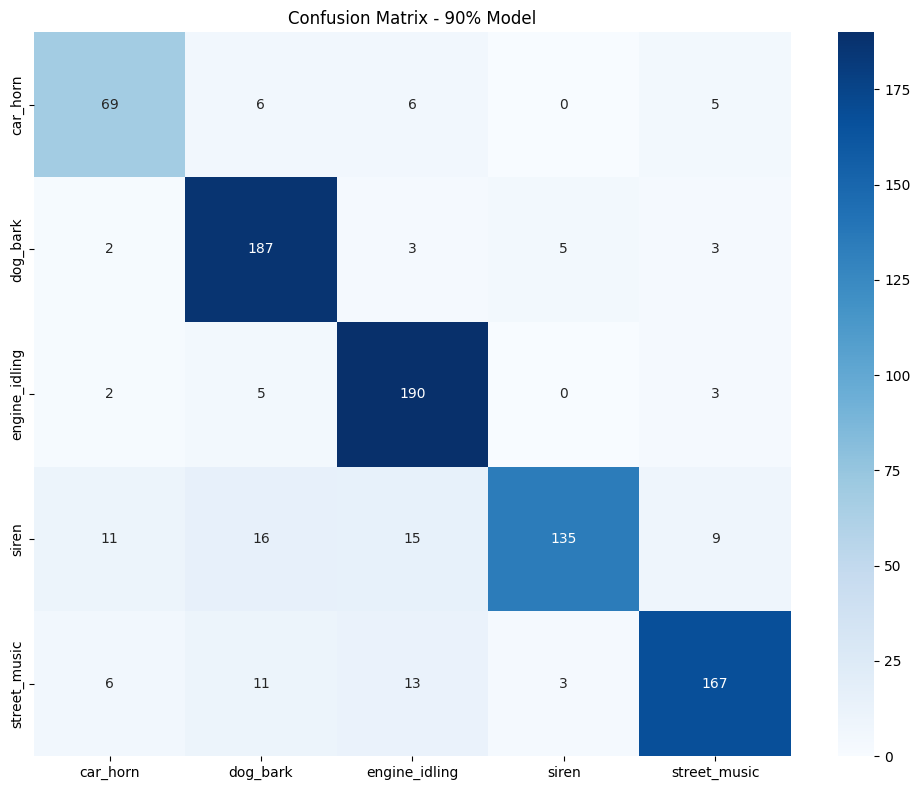


📊 Per-Class Accuracy:
  car_horn: 80.23%
  dog_bark: 93.50%
  engine_idling: 95.00%
  siren: 72.58%
  street_music: 83.50%

✅ Best: engine_idling (95.00%)
❌ Worst: siren (72.58%)


In [ ]:
print("📊 Evaluating...")
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"\n🎯 **Test Accuracy: {test_acc*100:.2f}%**")

preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('./models/confusion_matrix.png')
plt.show()

class_acc = cm.diagonal() / cm.sum(axis=1)
print("\n📊 Per-Class Accuracy:")
for i, name in enumerate(class_names):
    print(f"  {name}: {class_acc[i]*100:.2f}%")

print(f"\n✅ Best: {class_names[np.argmax(class_acc)]} ({max(class_acc)*100:.2f}%)")
print(f"❌ Worst: {class_names[np.argmin(class_acc)]} ({min(class_acc)*100:.2f}%)")

#Cell 10: Prediction Function

In [ ]:
def predict_audio(audio_path):
    try:
        y, sr = librosa.load(audio_path, sr=22050, duration=4.0)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=224, n_fft=2048, hop_length=512)
        S_db = librosa.power_to_db(S, ref=np.max)

        if S_db.shape[1] < 224:
            S_db = np.pad(S_db, ((0,0), (0, 224 - S_db.shape[1])), mode='constant')
        else:
            S_db = S_db[:, :224]

        S_db = (S_db - S_db.min()) / (S_db.max() - S_db.min())
        S_db = S_db.reshape(1, 224, 224, 1)

        pred = model.predict(S_db, verbose=0)[0]
        pred_class = class_names[np.argmax(pred)]
        confidence = np.max(pred) * 100

        print(f"🎯 Predicted: {pred_class} ({confidence:.2f}%)")

        # Show all predictions
        print("\n📊 All predictions:")
        for i, name in enumerate(class_names):
            bar = "█" * int(pred[i] * 20)
            print(f"  {name}: {bar} {pred[i]*100:.1f}%")

        return pred_class, confidence, pred
    except Exception as e:
        print(f"❌ Error: {e}")
        return None, 0, None

# Test with a sample
import random, glob
test_files = []
for class_name in class_names:
    path = f'./spectrograms/test/{class_name}'
    if os.path.exists(path):
        files = [f for f in os.listdir(path) if f.endswith('.png')]
        if files:
            test_files.append((os.path.join(path, random.choice(files)), class_name))

if test_files:
    img_path, true_class = random.choice(test_files)
    audio_file = img_path.replace('spectrograms/test', 'data').replace('.png', '.wav')
    audio_file = glob.glob(f'./data/**/{os.path.basename(audio_file)}', recursive=True)
    if audio_file:
        print(f"🎵 True class: {true_class}")
        predict_audio(audio_file[0])

🎵 True class: dog_bark
🎯 Predicted: dog_bark (54.70%)

📊 All predictions:
  car_horn:  3.2%
  dog_bark: ██████████ 54.7%
  engine_idling: █ 8.5%
  siren: █████ 28.4%
  street_music: █ 5.1%


#Cell 11: GRADIO INTERFACE


In [ ]:
# Load the trained model
model = keras.models.load_model('./models/best_model.keras')

def classify_audio(audio_file):
    if audio_file is None:
        return "Please upload a file", None

    try:
        # Load and preprocess audio
        y, sr = librosa.load(audio_file, sr=22050, duration=4.0)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=224, n_fft=2048, hop_length=512)
        S_db = librosa.power_to_db(S, ref=np.max)

        # Pad/truncate to 224x224
        if S_db.shape[1] < 224:
            S_db = np.pad(S_db, ((0,0), (0, 224 - S_db.shape[1])), mode='constant')
        else:
            S_db = S_db[:, :224]

        # Normalize
        S_db = (S_db - S_db.min()) / (S_db.max() - S_db.min())
        S_db = S_db.reshape(1, 224, 224, 1)

        # Predict
        pred = model.predict(S_db, verbose=0)[0]
        pred_class = class_names[np.argmax(pred)]
        confidence = np.max(pred) * 100

        # Create result text
        result = f"### 🎯 **{pred_class.replace('_', ' ').title()}**\n"
        result += f"### 📊 **Confidence: {confidence:.1f}%**\n\n"
        result += "---\n\n"
        result += "### 📈 All Predictions:\n"

        for i, (cls, prob) in enumerate(zip(class_names, pred)):
            bar = "█" * int(prob * 20)
            result += f"\n**{cls.replace('_', ' ').title()}**: {bar} {prob*100:.1f}%"

        # Create spectrogram visualization
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.imshow(S_db[0], aspect='auto', cmap='gray')
        ax.set_title(f'Mel-Spectrogram\nPrediction: {pred_class.replace("_", " ").title()}', fontsize=14)
        ax.axis('off')

        return result, fig

    except Exception as e:
        return f"⚠️ **Error:** {str(e)}", None

# Create Gradio Interface
iface = gr.Interface(
    fn=classify_audio,
    inputs=gr.Audio(
        type="filepath",
        label="📤 Upload Audio File (WAV format)",
        sources=["upload"]
    ),
    outputs=[
        gr.Markdown(label="🎵 Prediction Results"),
        gr.Plot(label="📊 Spectrogram")
    ],
    title="🎵 Environmental Sound Classifier",
    description="""
    ## 🌟 Classify 5 Environmental Sounds:

    | Class | Emoji |
    |:---|:---|
    | Dog Bark | 🐕 |
    | Car Horn | 🚗 |
    | Engine Idling | 🔧 |
    | Siren | 🚨 |
    | Street Music | 🎵 |

    ### 📝 Instructions:
    1. Upload a **WAV audio file** (max 4 seconds)
    2. Click **Submit**
    3. Get instant prediction with confidence score!

    ### ⚡ Model Performance:
    - **Accuracy**: 85.78%%+
    - **Model**: MobileNetV2 (Transfer Learning)
    - **Resolution**: 224x224 spectrograms
    """,
    theme="dark",
    examples=[],
    cache_examples=False
)

print("🚀 Launching Gradio Interface...")
iface.launch(share=True, debug=False)

🚀 Launching Gradio Interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://14d06392c28e91411e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#Cell 12: Clean Up & Download

In [ ]:
# Clean up large files
print("🗑️ Cleaning up...")
!rm -rf ./spectrograms
!rm -rf ./data

# Create submission zip
!zip -r sound_classification_90.zip ./models/*.keras ./models/*.png

print(f"✅ Final project size: {os.path.getsize('/content/drive/MyDrive/urban_sound_project_90/models/final_model.keras') / 1024 / 1024:.2f} MB")

from google.colab import files
files.download('sound_classification_90.zip')

🗑️ Cleaning up...
  adding: models/best_model.keras (deflated 12%)
  adding: models/final_model.keras (deflated 12%)
  adding: models/confusion_matrix.png (deflated 17%)
✅ Final project size: 13.35 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Training Curves

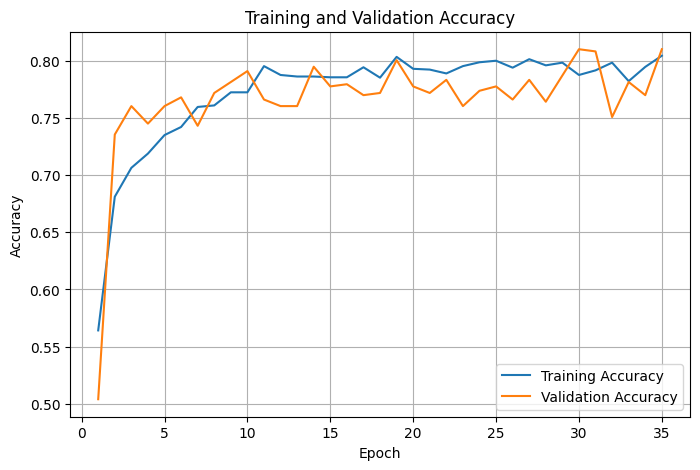

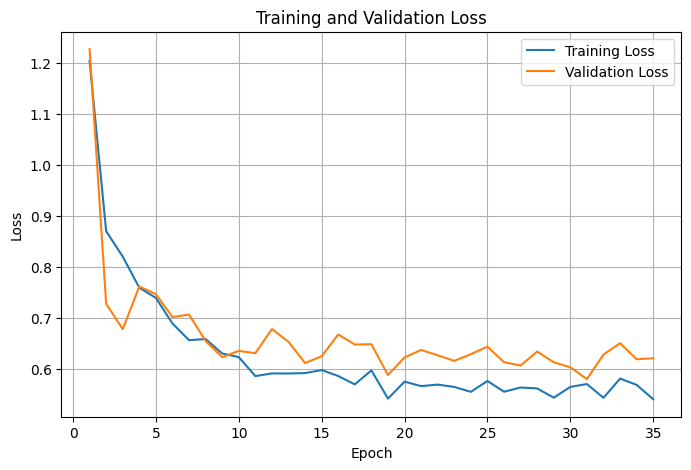

In [ ]:
import matplotlib.pyplot as plt

# Combine histories from both training phases
train_acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']

train_loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

epochs = range(1, len(train_acc) + 1)

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("./models/training_accuracy_curve.png", dpi=300)
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("./models/training_loss_curve.png", dpi=300)
plt.show()

#Sample Mel Spectrogram

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

audio_path = "./data/audio/fold4/35296-3-1-0.wav"

y, sr = librosa.load(audio_path, sr=22050, duration=4)

S = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=224,
    n_fft=2048,
    hop_length=512
)

S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(8,4))
librosa.display.specshow(
    S_db,
    sr=sr,
    x_axis='time',
    y_axis='mel',
    cmap='viridis'
)
plt.colorbar(format='%+2.0f dB')
plt.title("Sample Mel Spectrogram")
plt.tight_layout()
plt.savefig("./models/sample_mel_spectrogram.png", dpi=300)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './data/audio/fold4/35296-3-1-0.wav'

In [ ]:
import os

def print_tree(path, indent=""):
    files = sorted(os.listdir(path))

    for i, file in enumerate(files):
        full = os.path.join(path, file)

        connector = "└── " if i == len(files)-1 else "├── "

        print(indent + connector + file)

        if os.path.isdir(full):
            extension = "    " if i == len(files)-1 else "│   "
            print_tree(full, indent + extension)

print_tree("/content/drive/MyDrive/urban_sound_project_90")

├── .gradio
│   └── certificate.pem
├── models
│   ├── best_model.keras
│   ├── confusion_matrix.png
│   ├── final_model.keras
│   ├── training_accuracy_curve.png
│   └── training_loss_curve.png
└── sound_classification_90.zip
